## HW3: Trip Advisor Hotel Reviews 

Гандзюк Д.А. AITH25


In [1]:
import os
import re
import glob
import math
import random
from dataclasses import dataclass
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

from torchmetrics.classification import Accuracy, F1Score

from sklearn.model_selection import train_test_split


@dataclass
class Config:
    seed: int = 42

   
    max_vocab_size: int = 20_000
    min_token_freq: int = 2
    max_len: int = 256

    batch_size: int = 64  
    num_workers: int = 0  # Windows

    
    max_epochs: int = 8
    lr: float = 2e-3
    weight_decay: float = 1e-4

    early_stopping_patience: int = 2

    # Логи
    logs_dir: str = "./hw_3/logs"


cfg = Config()


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


pl.seed_everything(cfg.seed, workers=True)
set_seed(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("pytorch_lightning:", pl.__version__)
print("cuda available:", torch.cuda.is_available())
print("device:", device)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

Seed set to 42


torch: 2.7.0+cu118
pytorch_lightning: 2.6.0
cuda available: True
device: cuda


In [2]:
import importlib
import sys
import subprocess


def ensure_package(pip_name: str, import_name: str | None = None) -> None:
    name = import_name or pip_name
    try:
        importlib.import_module(name)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])


ensure_package("kagglehub")

# проверка
import kagglehub  # noqa: F401
print("kagglehub ready")

kagglehub ready


## 1) Данные: загрузка (kagglehub) и подготовка

Датасет: **Trip Advisor Hotel Reviews**.



In [3]:
import kagglehub


def robust_kagglehub_dataset_download(handle: str) -> str:
    """kagglehub иногда пытается "распаковать" файл, который не является zip/tar.
    В таком случае ловим ошибку и читаем данные из кеша."""

    try:
        return kagglehub.dataset_download(handle)
    except ValueError as e:
        if "Unsupported archive type" not in str(e):
            raise

        owner, ds = handle.split("/", 1)
        cache_dir = os.path.join(os.path.expanduser("~"), ".cache", "kagglehub", "datasets", owner, ds)
        print("kagglehub extract failed; fallback to cache:", cache_dir)
        return cache_dir


# Download latest version
kaggle_path = robust_kagglehub_dataset_download("andrewmvd/trip-advisor-hotel-reviews")
print("Path to dataset files:", kaggle_path)

csv_files = glob.glob(os.path.join(kaggle_path, "**", "*.csv"), recursive=True)
archive_files = glob.glob(os.path.join(kaggle_path, "**", "*.archive"), recursive=True)

print("CSV files:")
for p in csv_files:
    print(" -", p)
print("ARCHIVE files:")
for p in archive_files:
    print(" -", p)

if len(csv_files) > 0:
    data_path = csv_files[0]
    df = pd.read_csv(data_path)
elif len(archive_files) > 0:
    # иногда это CSV, просто сохранённый без расширения
    data_path = archive_files[0]
    df = pd.read_csv(data_path)
else:
    raise FileNotFoundError("Не нашли ни .csv, ни *.archive в результате kagglehub")

print("using:", data_path)
print("shape:", df.shape)
df.head()

Path to dataset files: C:\Users\crazy\.cache\kagglehub\datasets\andrewmvd\trip-advisor-hotel-reviews\versions\2
CSV files:
 - C:\Users\crazy\.cache\kagglehub\datasets\andrewmvd\trip-advisor-hotel-reviews\versions\2\tripadvisor_hotel_reviews.csv
ARCHIVE files:
using: C:\Users\crazy\.cache\kagglehub\datasets\andrewmvd\trip-advisor-hotel-reviews\versions\2\tripadvisor_hotel_reviews.csv
shape: (20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [4]:
print(df.columns)


col_review = None
col_rating = None

for c in df.columns:
    cl = c.lower()
    if col_review is None and ("review" in cl or "text" in cl):
        col_review = c
    if col_rating is None and ("rating" in cl or "score" in cl):
        col_rating = c

if col_review is None or col_rating is None:
    raise ValueError(f"Не нашли колонки review/rating. columns={list(df.columns)}")

print("review column:", col_review)
print("rating column:", col_rating)

# Чистим NaN и приводим типы
raw_texts = df[col_review].astype(str).tolist()
raw_ratings = df[col_rating].astype(int).to_numpy()

print("rating min/max:", raw_ratings.min(), raw_ratings.max())
print("rating distribution:\n", pd.Series(raw_ratings).value_counts().sort_index())

Index(['Review', 'Rating'], dtype='object')
review column: Review
rating column: Rating
rating min/max: 1 5
rating distribution:
 1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


### Предобработка текста

Что делаем и зачем:
- **lowercase** — уменьшает словарь
- **убираем HTML/мусорные символы** 
- **токенизация простым regex** 
- **обрезка/паддинг до `max_len`** — фиксируем длину последовательности для батчинга

Дальше строим словарь **только по train** (чтобы не было утечки).

In [5]:
_token_re = re.compile(r"[a-z0-9]+(?:'[a-z0-9]+)?")


def normalize_text(text: str) -> str:
    text = text.lower()
    # на всякий: вычищаем простейшие html-теги
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize(text: str) -> list[str]:
    text = normalize_text(text)
    return _token_re.findall(text)


# быстрый sanity-check
print(tokenize("<br /> Great hotel!!! 10/10, I'd come again."))

['great', 'hotel', '10', '10', "i'd", 'come', 'again']


### Split 60/20/20 со стратификацией

Стратифицируем по рейтингу, чтобы доли классов были одинаковыми в train/val/test.

In [6]:
# y: 0..4
labels = raw_ratings - 1
if labels.min() != 0 or labels.max() != 4:
    raise ValueError(f"Ожидали рейтинги 1..5. min/max={raw_ratings.min()}/{raw_ratings.max()}")

X = np.array(raw_texts, dtype=object)
y = labels.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=cfg.seed,
    stratify=y,
)

# из оставшихся 40% делаем 20/20 => половина
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=cfg.seed,
    stratify=y_temp,
)

print("sizes:", len(X_train), len(X_val), len(X_test))
print("train dist:\n", pd.Series(y_train).value_counts(normalize=True).sort_index())
print("val dist:\n", pd.Series(y_val).value_counts(normalize=True).sort_index())
print("test dist:\n", pd.Series(y_test).value_counts(normalize=True).sort_index())

sizes: 12294 4098 4099
train dist:
 0    0.069383
1    0.087522
2    0.106556
3    0.294697
4    0.441842
Name: proportion, dtype: float64
val dist:
 0    0.069302
1    0.087360
2    0.106637
3    0.294778
4    0.441923
Name: proportion, dtype: float64
test dist:
 0    0.069285
1    0.087582
2    0.106611
3    0.294706
4    0.441815
Name: proportion, dtype: float64


### Vocabulary (только train) и кодирование

- `PAD=0`, `UNK=1`
- Ограничиваем словарь `max_vocab_size`
- Токены с частотой < `min_token_freq` отбрасываем
- Последовательности приводим к длине `max_len` (trunc/pad)

Это простая и честная baseline-подготовка для CNN/LSTM без предобученных эмбеддингов.

In [7]:
def build_vocab(texts: np.ndarray) -> tuple[dict[str, int], list[str]]:
    counter: Counter[str] = Counter()
    for t in texts:
        counter.update(tokenize(str(t)))

    # фильтрация по min freq
    items = [(tok, cnt) for tok, cnt in counter.items() if cnt >= cfg.min_token_freq]
    items.sort(key=lambda x: x[1], reverse=True)

    # спец-токены
    itos = ["<pad>", "<unk>"]
    for tok, _ in items[: max(0, cfg.max_vocab_size - len(itos))]:
        itos.append(tok)

    stoi = {tok: i for i, tok in enumerate(itos)}
    return stoi, itos


stoi, itos = build_vocab(X_train)
print("vocab size:", len(itos))
print("sample tokens:", itos[:20])

PAD_ID = stoi["<pad>"]
UNK_ID = stoi["<unk>"]


def encode(text: str) -> tuple[list[int], int]:
    toks = tokenize(text)
    ids = [stoi.get(tok, UNK_ID) for tok in toks]

    # длина до паддинга (для LSTM pack нельзя 0)
    length = min(len(ids), cfg.max_len)
    length = max(1, int(length))

    ids = ids[: cfg.max_len]
    if len(ids) < cfg.max_len:
        ids = ids + [PAD_ID] * (cfg.max_len - len(ids))
    return ids, length


ids0, len0 = encode(str(X_train[0]))
print("encoded len (true/padded):", len0, len(ids0))
print("first 30 ids:", ids0[:30])

vocab size: 20000
sample tokens: ['<pad>', '<unk>', 'hotel', 'room', 'not', 'great', "n't", 'good', 'staff', 'stay', 'did', 'just', 'rooms', 'nice', 'no', 'location', 'stayed', 'night', 'service', 'time']
encoded len (true/padded): 69 256
first 30 ids: [36, 2, 15, 36, 171, 2, 514, 15, 131, 202, 3221, 257, 193, 233, 3013, 15, 86, 1781, 1048, 2197, 15531, 533, 430, 992, 3565, 12, 206, 312, 95, 350]


In [8]:
class ReviewsDataset(Dataset):
    def __init__(self, texts: np.ndarray, labels: np.ndarray):
        self.texts = texts
        self.labels = labels

        # предкодируем один раз — быстрее и полностью детерминированно
        ids_list: list[list[int]] = []
        lens_list: list[int] = []
        for t in self.texts:
            ids, ln = encode(str(t))
            ids_list.append(ids)
            lens_list.append(ln)

        self.input_ids = torch.tensor(ids_list, dtype=torch.long)
        self.lengths = torch.tensor(lens_list, dtype=torch.long)
        self.y = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self) -> int:
        return int(self.y.shape[0])

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        return self.input_ids[idx], self.lengths[idx], self.y[idx]


class TripAdvisorDataModule(pl.LightningDataModule):
    def __init__(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: np.ndarray,
        y_val: np.ndarray,
        X_test: np.ndarray,
        y_test: np.ndarray,
        batch_size: int = 64,
        num_workers: int = 0,
    ):
        super().__init__()
        self.save_hyperparameters(ignore=["X_train", "y_train", "X_val", "y_val", "X_test", "y_test"])

        self._X_train = X_train
        self._y_train = y_train
        self._X_val = X_val
        self._y_val = y_val
        self._X_test = X_test
        self._y_test = y_test

        self.train_ds = None
        self.val_ds = None
        self.test_ds = None

    def setup(self, stage: str | None = None) -> None:
        if stage in (None, "fit"):
            self.train_ds = ReviewsDataset(self._X_train, self._y_train)
            self.val_ds = ReviewsDataset(self._X_val, self._y_val)
        if stage in (None, "test"):
            self.test_ds = ReviewsDataset(self._X_test, self._y_test)

    def train_dataloader(self) -> DataLoader:
        return DataLoader(
            self.train_ds,
            batch_size=self.hparams.batch_size,
            shuffle=True,
            num_workers=self.hparams.num_workers,
            pin_memory=torch.cuda.is_available(),
        )

    def val_dataloader(self) -> DataLoader:
        return DataLoader(
            self.val_ds,
            batch_size=self.hparams.batch_size,
            shuffle=False,
            num_workers=self.hparams.num_workers,
            pin_memory=torch.cuda.is_available(),
        )

    def test_dataloader(self) -> DataLoader:
        return DataLoader(
            self.test_ds,
            batch_size=self.hparams.batch_size,
            shuffle=False,
            num_workers=self.hparams.num_workers,
            pin_memory=torch.cuda.is_available(),
        )


dm = TripAdvisorDataModule(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    batch_size=cfg.batch_size,
    num_workers=cfg.num_workers,
)

dm.setup("fit")
xb_ids, xb_len, yb = next(iter(dm.train_dataloader()))
print(xb_ids.shape, xb_len.shape, yb.shape)
print("lengths min/max:", xb_len.min().item(), xb_len.max().item())

torch.Size([64, 256]) torch.Size([64]) torch.Size([64])
lengths min/max: 15 256


### Выбор batch_size

Я беру `batch_size=64` как стабильный дефолт для текста длины `max_len=256`:
- LSTM заметно более прожорлив по памяти, чем CNN
- 64 обычно хорошо утилизирует GPU, не упираясь в память (особенно на Windows)

Если у тебя много VRAM, можно поднять до 128; если ловишь OOM — опустить до 32.

## 2) Модели на PyTorch Lightning

Метрики (валидация/тест):
- **Accuracy**
- **Macro-F1** (важно при возможном дисбалансе рейтингов)

Дальше реализуем:
- **TextCNN (Conv1d)** — baseline
- **TextLSTM (LSTM)** — baseline
- **Improved TextCNN** — несколько размеров свёрток (3/4/5) + dropout

In [9]:
NUM_CLASSES = 5
VOCAB_SIZE = len(itos)


class BaseReviewClassifier(pl.LightningModule):
    def __init__(self, lr: float = 2e-3, weight_decay: float = 1e-4):
        super().__init__()
        self.save_hyperparameters()

        self.train_acc = Accuracy(task="multiclass", num_classes=NUM_CLASSES)
        self.val_acc = Accuracy(task="multiclass", num_classes=NUM_CLASSES)
        self.test_acc = Accuracy(task="multiclass", num_classes=NUM_CLASSES)

        self.train_f1 = F1Score(task="multiclass", num_classes=NUM_CLASSES, average="macro")
        self.val_f1 = F1Score(task="multiclass", num_classes=NUM_CLASSES, average="macro")
        self.test_f1 = F1Score(task="multiclass", num_classes=NUM_CLASSES, average="macro")

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError

    def _shared_step(self, batch, stage: str):
        input_ids, lengths, y = batch
        logits = self(input_ids, lengths)
        loss = nn.functional.cross_entropy(logits, y)

        preds = torch.argmax(logits, dim=1)

        if stage == "train":
            acc = self.train_acc(preds, y)
            f1 = self.train_f1(preds, y)
        elif stage == "val":
            acc = self.val_acc(preds, y)
            f1 = self.val_f1(preds, y)
        else:
            acc = self.test_acc(preds, y)
            f1 = self.test_f1(preds, y)

        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log(f"{stage}_acc", acc, prog_bar=True, on_epoch=True, on_step=False)
        self.log(f"{stage}_f1", f1, prog_bar=True, on_epoch=True, on_step=False)
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        self._shared_step(batch, "test")

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        return opt


class TextCNN(BaseReviewClassifier):
    def __init__(
        self,
        vocab_size: int,
        emb_dim: int = 128,
        num_filters: int = 128,
        kernel_size: int = 3,
        dropout: float = 0.2,
        lr: float = 2e-3,
        weight_decay: float = 1e-4,
    ):
        super().__init__(lr=lr, weight_decay=weight_decay)
        self.save_hyperparameters()

        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)
        self.conv = nn.Conv1d(emb_dim, num_filters, kernel_size=kernel_size, padding=kernel_size // 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters, NUM_CLASSES)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        x = self.emb(input_ids)  # [B, L, E]
        x = x.transpose(1, 2)  # [B, E, L]
        x = torch.relu(self.conv(x))  # [B, C, L]
        x = torch.max(x, dim=2).values  # global max pool -> [B, C]
        x = self.dropout(x)
        logits = self.fc(x)
        return logits


class TextCNNMultiKernel(BaseReviewClassifier):
    def __init__(
        self,
        vocab_size: int,
        emb_dim: int = 128,
        num_filters: int = 128,
        kernel_sizes: tuple[int, ...] = (3, 4, 5),
        dropout: float = 0.3,
        lr: float = 2e-3,
        weight_decay: float = 1e-4,
    ):
        super().__init__(lr=lr, weight_decay=weight_decay)
        self.save_hyperparameters()

        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)
        self.convs = nn.ModuleList(
            [nn.Conv1d(emb_dim, num_filters, kernel_size=k, padding=k // 2) for k in kernel_sizes]
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), NUM_CLASSES)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        x = self.emb(input_ids)  # [B, L, E]
        x = x.transpose(1, 2)  # [B, E, L]

        pooled = []
        for conv in self.convs:
            h = torch.relu(conv(x))  # [B, C, L]
            h = torch.max(h, dim=2).values  # [B, C]
            pooled.append(h)

        z = torch.cat(pooled, dim=1)  # [B, C*K]
        z = self.dropout(z)
        logits = self.fc(z)
        return logits


class TextLSTM(BaseReviewClassifier):
    def __init__(
        self,
        vocab_size: int,
        emb_dim: int = 128,
        hidden_dim: int = 128,
        num_layers: int = 1,
        dropout: float = 0.2,
        bidirectional: bool = False,
        lr: float = 2e-3,
        weight_decay: float = 1e-4,
    ):
        super().__init__(lr=lr, weight_decay=weight_decay)
        self.save_hyperparameters()

        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(out_dim, NUM_CLASSES)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        x = self.emb(input_ids)  # [B, L, E]

        # pack — игнорим PAD внутри LSTM
        lengths_cpu = lengths.detach().cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths_cpu,
            batch_first=True,
            enforce_sorted=False,
        )
        packed_out, (h_n, c_n) = self.lstm(packed)

        # h_n: [num_layers * num_directions, B, H]
        if self.hparams.bidirectional:
            # последний слой: concat forward/backward
            h_fwd = h_n[-2]
            h_bwd = h_n[-1]
            h = torch.cat([h_fwd, h_bwd], dim=1)
        else:
            h = h_n[-1]

        h = self.dropout(h)
        logits = self.fc(h)
        return logits

## 3) Обучение и сравнение

Ниже обучаем 3 модели с одинаковыми настройками

Логирование: **CSVLogger** 

Мониторим `val_f1` и сохраняем лучший чекпоинт (early stopping тоже по `val_f1`).

In [10]:
import matplotlib.pyplot as plt

os.makedirs(cfg.logs_dir, exist_ok=True)


def train_and_test(model: pl.LightningModule, name: str):
    logger = CSVLogger(save_dir=cfg.logs_dir, name=name)

    ckpt = ModelCheckpoint(
        monitor="val_f1",
        mode="max",
        save_top_k=1,
        filename="best-{epoch:02d}-{val_f1:.4f}",
    )

    early = EarlyStopping(
        monitor="val_f1",
        mode="max",
        patience=cfg.early_stopping_patience,
    )

    trainer = pl.Trainer(
        max_epochs=cfg.max_epochs,
        accelerator="auto",
        devices="auto",
        deterministic=True,
        logger=logger,
        callbacks=[early, ckpt],
        log_every_n_steps=10,
        enable_progress_bar=True,
    )

    trainer.fit(model, datamodule=dm)
    test_res = trainer.test(model, datamodule=dm, ckpt_path="best")

    return {
        "name": name,
        "log_dir": logger.log_dir,
        "best_model_path": ckpt.best_model_path,
        **test_res[0],
    }


results = []

# 1) CNN baseline
model_cnn = TextCNN(vocab_size=VOCAB_SIZE, emb_dim=128, num_filters=128, kernel_size=3, dropout=0.2, lr=cfg.lr)
results.append(train_and_test(model_cnn, "cnn_baseline"))

# 2) LSTM baseline
model_lstm = TextLSTM(vocab_size=VOCAB_SIZE, emb_dim=128, hidden_dim=128, num_layers=1, dropout=0.2, lr=cfg.lr)
results.append(train_and_test(model_lstm, "lstm_baseline"))

# 3) Improved CNN
model_cnn2 = TextCNNMultiKernel(
    vocab_size=VOCAB_SIZE,
    emb_dim=128,
    num_filters=128,
    kernel_sizes=(3, 4, 5),
    dropout=0.3,
    lr=cfg.lr,
)
results.append(train_and_test(model_cnn2, "cnn_multikernel"))

res_df = pd.DataFrame(results)
res_df

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | train_acc | MulticlassAccuracy | 0      | train | 0    
1 | val_acc   | MulticlassAccuracy | 0      | train | 0    
2 | test_acc  | MulticlassAccuracy | 0      | train | 0    
3 | train_f1  | MulticlassF1Score  | 0      | train | 0    
4 | val_f1    | MulticlassF1Score  | 0      | train | 0    
5 | test_f1   | MulticlassF1Score  | 0      | train | 0    
6 | emb       | Embedding          | 2.6 M  | train | 0    
7 | conv      | Conv1d             | 49.3 K | train | 0    
8 | dropout   | Dropout            | 0      | train | 0    
9 | fc        | Linear             | 645    | train | 0    
-----------------------------------------------------------------
2.6 M     Trainable params
0         Non-trainable params
2.6 M     Total params
10.440    Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
0         Tota

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Loaded model weights from the checkpoint at ./hw_3/logs\cnn_multikernel\version_2\checkpoints\best-epoch=06-val_f1=0.4968.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.6089289784431458
         test_f1            0.4941708743572235
        test_loss           1.0597994327545166
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,name,log_dir,best_model_path,test_loss,test_acc,test_f1
0,cnn_baseline,./hw_3/logs\cnn_baseline\version_2,./hw_3/logs\cnn_baseline\version_2\checkpoints...,0.906915,0.598927,0.504833
1,lstm_baseline,./hw_3/logs\lstm_baseline\version_2,./hw_3/logs\lstm_baseline\version_2\checkpoint...,1.268269,0.547939,0.434084
2,cnn_multikernel,./hw_3/logs\cnn_multikernel\version_2,./hw_3/logs\cnn_multikernel\version_2\checkpoi...,1.059799,0.608929,0.494171


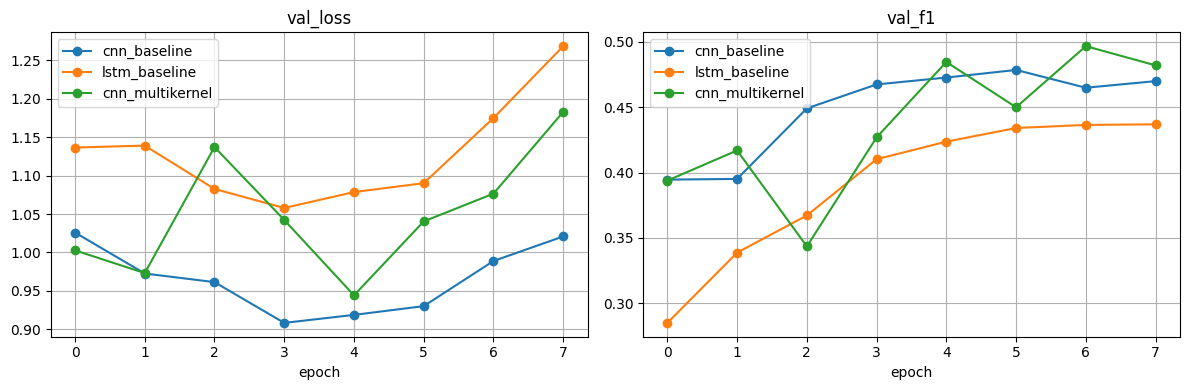

In [16]:
def load_epoch_metrics(log_dir: str) -> pd.DataFrame:
    """CSVLogger пишет несколько строк на одну эпоху (train/val в разное время).
    Здесь агрегируем по epoch так, чтобы val_* не терялись (max игнорирует NaN)."""

    path = os.path.join(log_dir, "metrics.csv")
    m = pd.read_csv(path)

    if "epoch" not in m.columns:
        return m

    # max по числовым колонкам = берём не-NaN значения (val_* обычно в другой строке, чем train_*)
    agg = {"step": "max"}
    for c in m.columns:
        if c in ("epoch", "step"):
            continue
        agg[c] = "max"

    out = m.groupby("epoch", as_index=False).agg(agg).sort_values("epoch").reset_index(drop=True)
    return out


def plot_curves(results_df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for _, row in results_df.iterrows():
        m = load_epoch_metrics(row["log_dir"])
        label = row["name"]

        if "val_loss" in m.columns:
            axes[0].plot(m["epoch"], m["val_loss"], marker="o", label=label)
        if "val_f1" in m.columns:
            axes[1].plot(m["epoch"], m["val_f1"], marker="o", label=label)

    axes[0].set_title("val_loss")
    axes[0].set_xlabel("epoch")
    axes[0].grid(True)

    axes[1].set_title("val_f1")
    axes[1].set_xlabel("epoch")
    axes[1].grid(True)

    for ax in axes:
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_curves(res_df)

## 4) Выводы

По результатам (ориентируемся прежде всего на **Macro-F1 на тесте**, потому что классы несбалансированы):
- **Лучшее качество** показал `cnn_baseline` (test_f1 ≈ 0.505). 
- **Усложнение CNN** до `cnn_multikernel` в этой конфигурации **не дало прироста Macro-F1** (хотя Accuracy чуть выше). Вероятная причина — модель лучше подстраивается под частые классы (4–5), но хуже держит редкие (1–2), из-за чего падает Macro-F1.
- **LSTM baseline** оказался слабее по качеству (и по сходимости): val_f1 растёт медленнее и выходит на плато ниже.
- По динамике `train_*` vs `val_*` видны **признаки переобучения после пика val_f1**: train_loss продолжает падать, train_f1 расти, а val_loss растёт/val_f1 стагнирует. Поэтому выбор **лучшего чекпоинта по val_f1** и early stopping — корректная стратегия.

Что можно улучшить дальше (если нужно): увеличить `emb_dim/hidden_dim`, добавить bidirectional LSTM, усилить регуляризацию (dropout/weight_decay), поиграть `max_len` и `max_vocab_size`.

In [19]:
show_cols = ["name", "test_loss", "test_acc", "test_f1"]
print(res_df[show_cols].sort_values("test_f1", ascending=False).to_string(index=False))

best = res_df.sort_values("test_f1", ascending=False).iloc[0]
print("\nЛучшая модель по test_f1:", best["name"], "test_f1=", float(best["test_f1"]))

val_peaks = []
for _, row in res_df.iterrows():
    m = load_epoch_metrics(row["log_dir"])
    m2 = m.dropna(subset=["val_f1"]) if "val_f1" in m.columns else m
    if "val_f1" in m2.columns and len(m2) > 0:
        i = int(m2["val_f1"].values.argmax())
        val_peaks.append(
            {
                "name": row["name"],
                "best_val_f1": float(m2.iloc[i]["val_f1"]),
                "best_val_epoch": int(m2.iloc[i]["epoch"]),
            }
        )

if len(val_peaks) > 0:
    print("\nЛучший val_f1 (и эпоха пика):")
    print(pd.DataFrame(val_peaks).sort_values("best_val_f1", ascending=False).to_string(index=False))


           name  test_loss  test_acc  test_f1
   cnn_baseline   0.906915  0.598927 0.504833
cnn_multikernel   1.059799  0.608929 0.494171
  lstm_baseline   1.268269  0.547939 0.434084

Лучшая модель по test_f1: cnn_baseline test_f1= 0.5048332214355469

Лучший val_f1 (и эпоха пика):
           name  best_val_f1  best_val_epoch
cnn_multikernel     0.496777               6
   cnn_baseline     0.478568               5
  lstm_baseline     0.436927               7


По **Macro-F1 на тесте** лучше всего сработал `cnn_baseline` (≈0.505). Это главный итог, т.к. Macro-F1 учитывает все классы равномерно.
- `cnn_multikernel` дал **чуть выше Accuracy**, но **хуже Macro-F1**. Это типично, когда модель лучше угадывает частые классы (4–5), но хуже редкие (1–2).
- `lstm_baseline` заметно отстаёт по обоим показателям - в этом baseline-наборе гиперпараметров CNN оказались более подходящими.
- По кривым видно **переобучение после пика val_f1**: train_loss падает и train_f1 растёт, а val_loss после минимума начинает расти/val_f1 перестаёт расти. Поэтому чекпоинт по `val_f1` (и early stopping) здесь оправданы."